In [25]:
import numpy as np
import matplotlib.pyplot as plt
import utils, pickle, model, train_utils
import theory_utils as t_utils

## 1. Input similarity (x0 overlap)

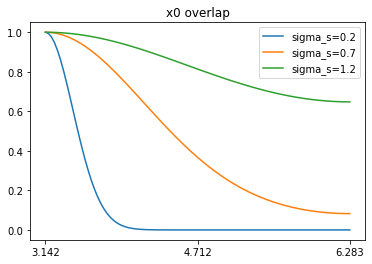

In [11]:
def x0_overlap(sigs):
    thetas = np.linspace(np.pi, 2*np.pi, 100)

    x0_pi = utils.make_x0(np.pi, sigs, 100)
    overlaps = np.zeros_like(thetas)
    for i in range(len(thetas)):
        overlaps[i] = utils.cos(x0_pi, utils.make_x0(thetas[i], sigs, 100))
    return overlaps

plt.figure()
plt.plot(thetas, x0_overlap(0.2), label='sigma_s=0.2')
plt.plot(thetas, x0_overlap(0.7), label='sigma_s=0.7')
plt.plot(thetas, x0_overlap(1.2), label='sigma_s=1.2')
plt.xticks([np.pi, np.pi*1.5, 2*np.pi]); plt.legend()
plt.title('x0 overlap')
plt.savefig('figures/raw/si_x0_overlap.svg')

## 2. Regimes of info loss in 2, 3 layer networks

See "Information in the first layer" in Figure_Making

## 3. Synaptic changes in two-layer networks

In [23]:
sig_w_array = np.linspace(0.1, 1.0, 30) # use for sig_s=1.2
# sig_w_array = np.linspace(0.5, 1.0, 30) # use for sig_s=0.2
load_saved_results = True
save_results = True
file_path = 'Saved Results/theory_2L_sigs0P6'
# file_path = 'Saved Results/THEORY_RESULTS_2_layers'

if load_saved_results:
    theory_dict = pickle.load(open(file_path, 'rb'))
    delw1_list = theory_dict['delw1']; delw2_list = theory_dict['delw2']; a_list = theory_dict['a']
    sig_w_array = theory_dict['sig_w']; active_inds_list = theory_dict['active_inds']
    OPs = theory_dict['OP']

parser = train_utils.Args('1D Gabor')
parser.add('loss', 'MSE') # MSE or BCE

# model parameters
parser.add('N', 1000); parser.add('Nhid', 1000); parser.add('n_layers', 2)

# task parameters
parser.add('sig_w', 0.5); parser.add('sig_s', 0.6); parser.add('theta', np.pi)
parser.add('noise_var', .01)

# Pro Forma parameters
parser.add('eta', 1e-4); parser.add('n_learn', 2000000); parser.add('n_train_trials', 500)
parser.add('n_test_trials', 10000); parser.add('test_interval', 500)

args = parser.parse_args()

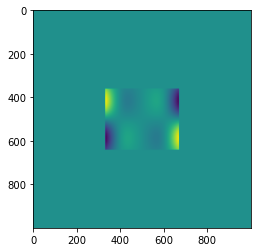

In [28]:
theory_ind = 2
_net = model.Model(args)
t_utils.load_theory_changes(_net, [delw1_list[theory_ind], delw2_list[theory_ind]], active_inds_list[theory_ind])

plt.figure()
plt.imshow(_net.Ws[1] - _net.init_weights[0].numpy())